# Synthetic Systems Engineering Graph — GNN Outlier Detection

This notebook generates a synthetic **Systems Engineering (SE) knowledge graph**, injects two types of structural outliers, converts the graph to PyTorch Geometric (PyG) format, and trains a **Graph Attention Network (GATv2)** to detect those outliers at the edge level.

**Graph schema**
- **Nodes**: Requirements (REQ), Functions (FUNC), Components (COMP), each arranged in a hierarchy by level
- **Edges**:
  - `hierarchy` — parent/child relationships within a domain
  - `allocated_to` — a requirement is assigned to a function or component
  - `satisfies` — a function/component fulfills a requirement

**Outlier types**
- **Type 1 (Missing Satisfaction)**: A requirement is allocated to a node, but no child of that node satisfies it
- **Type 2 (Illegal Satisfaction)**: A node satisfies a requirement that was never allocated to any of its parents

## 0. Imports

In [3]:
import sys
!{sys.executable} -m pip install torch_geometric

import random
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv, GATConv, GCNConv, SAGEConv, RGCNConv
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

## 1. Synthetic data generation

`generate_random_tree` builds a directed tree of a given node type with a forced path to `target_depth`, then expands randomly until `target_size` is reached.

`generate_se_dataset_with_outliers` composes three domain trees into one graph, adds random `allocated_to` edges from every requirement to one function and one component, infers `satisfies` edges from children to parent-allocated requirements, and probabilistically injects outliers.

**Key parameters**
| Parameter | Default | Effect |
|---|---|---|
| `p_missing_satisfy` | 0.1 | Probability a required `satisfies` link is omitted → Type 1 outlier |
| `p_illegal_satisfy` | 0.05 | Probability a node satisfies an unrelated requirement → Type 2 outlier |

> **Reproducibility note**: No global random seed is set. Add `random.seed(42)`, `np.random.seed(42)`, and `torch.manual_seed(42)` at the top for consistent results across runs.

In [6]:

def generate_random_tree(prefix, node_type, target_size, target_depth):
    G = nx.DiGraph()
    root_id = f"{prefix}_0"
    G.add_node(root_id, type=node_type, level=0)
    all_nodes = [root_id]

    # Force a path to target_depth
    current_node = root_id
    for d in range(1, target_depth + 1):
        new_id = f"{prefix}_{len(all_nodes)}"
        G.add_node(new_id, type=node_type, level=d)
        G.add_edge(new_id, current_node, relation='hierarchy')
        all_nodes.append(new_id)
        current_node = new_id

    # Expand randomly
    while len(all_nodes) < target_size:
        parent = random.choice(all_nodes)
        if G.nodes[parent]['level'] < target_depth:
            new_id = f"{prefix}_{len(all_nodes)}"
            new_level = G.nodes[parent]['level'] + 1
            G.add_node(new_id, type=node_type, level=new_level)
            G.add_edge(new_id, parent, relation='hierarchy')
            all_nodes.append(new_id)
    return G, all_nodes

def generate_se_dataset_with_outliers(
    req_size=100, req_depth=3,
    func_size=150, func_depth=4,
    comp_size=150, comp_depth=4,
    p_illegal_satisfy=0.05,
    p_missing_satisfy=0.1
):
    # 1. Generate Domain Trees
    req_tree, req_nodes = generate_random_tree("REQ", "requirement", req_size, req_depth)
    func_tree, func_nodes = generate_random_tree("FUNC", "function", func_size, func_depth)
    log_tree, log_nodes = generate_random_tree("COMP", "component", comp_size, comp_depth)
    G = nx.compose_all([req_tree, func_tree, log_tree])

    # 2. Random Allocations
    allocations = {node: [] for node in func_nodes + log_nodes}
    for req in req_nodes:
        target_f, target_c = random.choice(func_nodes), random.choice(log_nodes)
        # Default all allocations to "outlier=False"; logic will flip them if unsatisfied
        G.add_edge(req, target_f, relation='allocated_to', outlier=False)
        G.add_edge(req, target_c, relation='allocated_to', outlier=False)
        allocations[target_f].append(req)
        allocations[target_c].append(req)

    # 3. Satisfaction Logic + Outlier Insertion
    for node in func_nodes + log_nodes:
        n_type = G.nodes[node]['type']
        parents = [p for p in G.successors(node) if G.nodes[p]['type'] == n_type]

        # Outlier Type 1: Allocated req NOT satisfied by child (Missing Satisfy)
        for parent in parents:
            for req in allocations.get(parent, []):
                if random.random() > p_missing_satisfy:
                    G.add_edge(node, req, relation='satisfies', outlier=False)
                else:
                    # Flag the 'allocated_to' link as an outlier because it lacks a satisfy link
                    G[req][parent]['outlier'] = True

        # Outlier Type 2: Satisfies req NOT allocated to parent (Illegal Satisfy)
        if random.random() < p_illegal_satisfy:
            p_reqs_set = {r for p in parents for r in allocations.get(p, [])}
            illegal_pool = list(set(req_nodes) - p_reqs_set)
            if illegal_pool:
                wrong_req = random.choice(illegal_pool)
                G.add_edge(node, wrong_req, relation='satisfies', outlier=True)

    return G

## 2. Graph visualization

Two complementary views are provided.

`plot_se_system_v2` uses a spring-force layout. Good for seeing global connectivity and making outlier edges visually prominent.

`plot_se_clustered_by_domain_and_tier` places the three domains in separate columns with hierarchy level on the y-axis. Better for understanding the structured SE decomposition.

**Edge color key**
| Color | Edge type |
|---|---|
| Gray (faint) | Hierarchy — always valid |
| Red (faint) | Valid allocation |
| Orange (bold) | Type 1 outlier: unsatisfied allocation |
| Green (faint) | Valid satisfaction |
| Magenta (bold) | Type 2 outlier: illegal satisfaction |

In [7]:
def plot_se_system_v2(G):
    plt.figure(figsize=(16, 12))
    pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

    node_colors = [('#ADD8E6' if G.nodes[n]['type'] == 'requirement' else
                    '#90EE90' if G.nodes[n]['type'] == 'function' else '#FFD700') for n in G.nodes]

    # Edge filtering
    hier_edges = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'hierarchy']

    # Type 1: Orange allocations (missing satisfaction)
    alloc_val = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'allocated_to' and not d.get('outlier')]
    alloc_out = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'allocated_to' and d.get('outlier')]

    # Type 2: Magenta satisfaction (illegal link)
    sat_val = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'satisfies' and not d.get('outlier')]
    sat_out = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'satisfies' and d.get('outlier')]

    # Draw
    nx.draw_networkx_nodes(G, pos, node_size=80, node_color=node_colors, alpha=0.9)
    nx.draw_networkx_edges(G, pos, edgelist=hier_edges, edge_color='#CCCCCC', alpha=0.3, arrows=False)
    nx.draw_networkx_edges(G, pos, edgelist=alloc_val, edge_color='red', alpha=0.1)
    nx.draw_networkx_edges(G, pos, edgelist=alloc_out, edge_color='orange', width=2.5)
    nx.draw_networkx_edges(G, pos, edgelist=sat_val, edge_color='green', alpha=0.2)
    nx.draw_networkx_edges(G, pos, edgelist=sat_out, edge_color='magenta', width=2.5)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Req/Func/Comp', markerfacecolor='gray', markersize=10),
        Line2D([0], [0], color='orange', lw=2.5, label='Type 1: Unsatisfied Allocation'),
        Line2D([0], [0], color='magenta', lw=2.5, label='Type 2: Illegal Satisfaction'),
        Line2D([0], [0], color='red', lw=1, alpha=0.3, label='Valid Allocation'),
        Line2D([0], [0], color='green', lw=1, alpha=0.3, label='Valid Satisfaction')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.title("Systems Engineering Data: Outlier Analysis")
    plt.axis('off')
    plt.show()

In [8]:
def plot_se_clustered_by_domain_and_tier(G):
    plt.figure(figsize=(16, 10))

    # 1. Define Cluster spacing
    # x: Domain mapping (Requirements=0, Functions=5, Components=10)
    # y: Tier mapping (Level 0 at top, increasing levels going down)
    domain_x = {'requirement': 0, 'function': 5, 'component': 10}

    # Use a dictionary to keep track of how many nodes are at each (domain, level)
    # to spread them out horizontally within their cluster
    pos = {}
    counts = {}

    for node, data in G.nodes(data=True):
        d_type = data['type']
        level = data['level']

        # Initialize sub-cluster offsets
        cluster_key = (d_type, level)
        counts[cluster_key] = counts.get(cluster_key, 0) + 1

        # Position = (Base Domain X + minor jitter, -Level Y)
        # Jitter prevents nodes at the same tier from overlapping
        jitter = (counts[cluster_key] % 10) * 0.2
        pos[node] = (domain_x[d_type] + jitter, -level)

    # 2. Extract Edges (keeping outlier logic from before)
    hier_edges = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'hierarchy']
    alloc_val = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'allocated_to' and not d.get('outlier')]
    alloc_out = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'allocated_to' and d.get('outlier')]
    sat_val = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'satisfies' and not d.get('outlier')]
    sat_out = [(u,v) for u,v,d in G.edges(data=True) if d['relation'] == 'satisfies' and d.get('outlier')]

    # 3. Draw with the new clustered positions
    node_colors = [('#ADD8E6' if G.nodes[n]['type'] == 'requirement' else
                    '#90EE90' if G.nodes[n]['type'] == 'function' else '#FFD700') for n in G.nodes]

    nx.draw_networkx_nodes(G, pos, node_size=50, node_color=node_colors, alpha=0.8)
    nx.draw_networkx_edges(G, pos, edgelist=hier_edges, edge_color='gray', alpha=0.2, arrows=False)
    nx.draw_networkx_edges(G, pos, edgelist=alloc_val, edge_color='red', alpha=0.1)
    nx.draw_networkx_edges(G, pos, edgelist=alloc_out, edge_color='orange', width=2, label="Unsatisfied")
    nx.draw_networkx_edges(G, pos, edgelist=sat_val, edge_color='green', alpha=0.1)
    nx.draw_networkx_edges(G, pos, edgelist=sat_out, edge_color='magenta', width=2, label="Illegal")

    # Add column labels for clarity
    plt.text(0, 0.5, "REQUIREMENTS", fontweight='bold', ha='center')
    plt.text(5, 0.5, "FUNCTIONS", fontweight='bold', ha='center')
    plt.text(10, 0.5, "COMPONENTS", fontweight='bold', ha='center')

    plt.title("Clustered Systems Engineering Graph (Domain vs Tier)")
    plt.axis('off')
    plt.show()

### Generate a sample graph

A smaller graph (50 nodes per domain, 150 total) is used here to keep runtime short. The default sizes in `generate_se_dataset_with_outliers` are 100/150/150 (400 total).

> **Known issue — train/test size mismatch**: `test_gnn_consolidated` (Section 7) calls the generator with default sizes, so the test graphs are ~2.7x larger than the training graph. Pass the same sizes to both, or train on the default sizes, for a fair comparison.

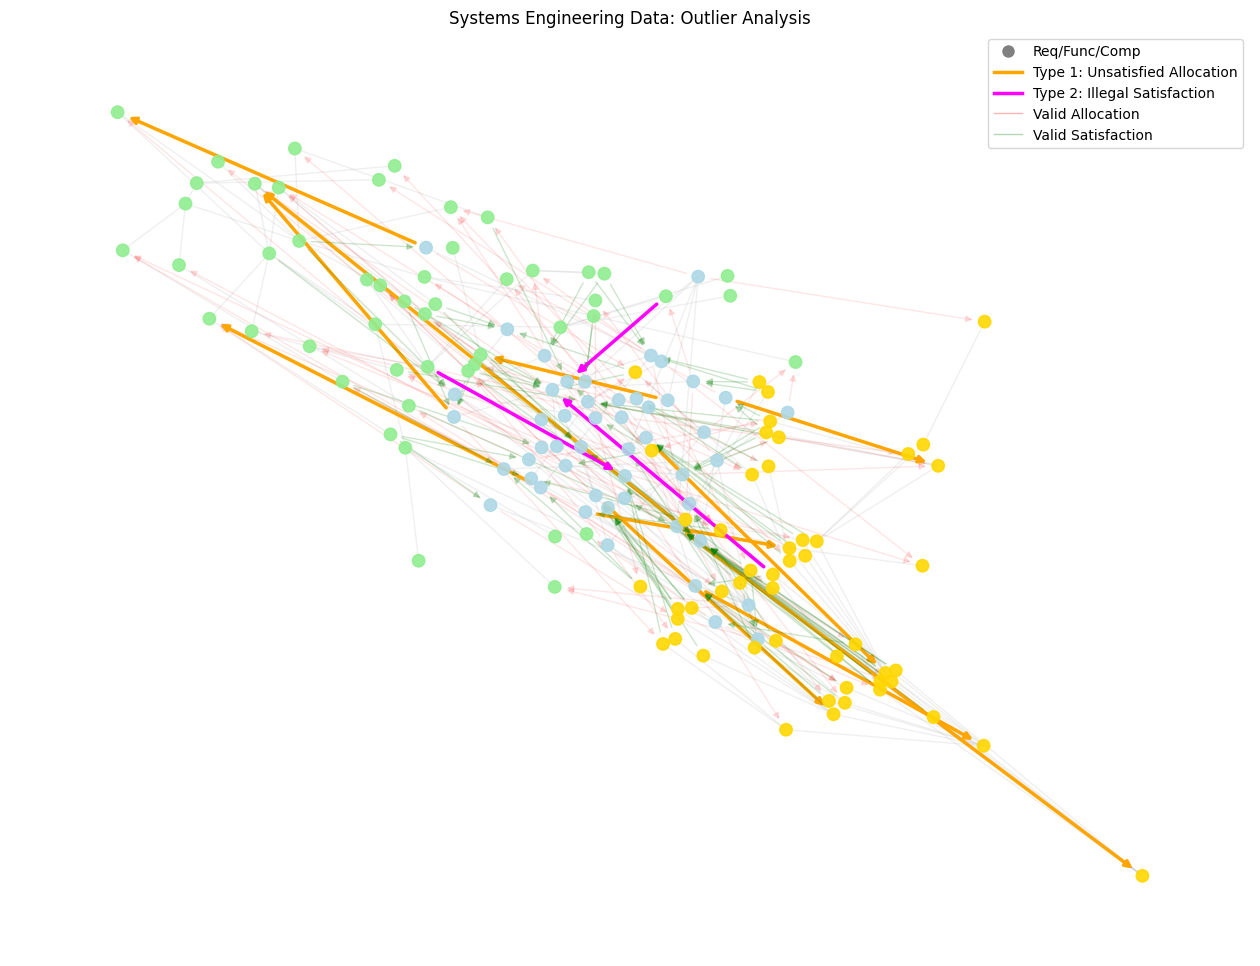

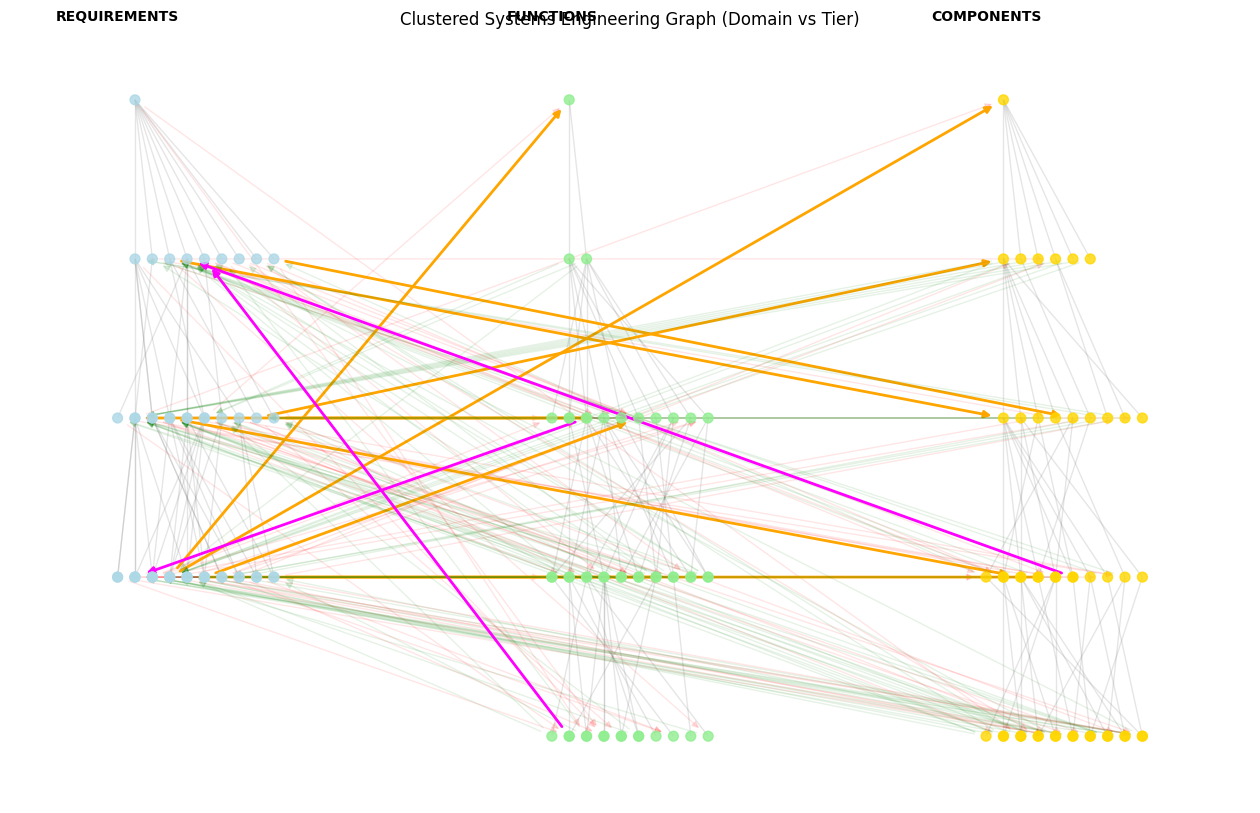

In [9]:
# Generate and Plot
g = generate_se_dataset_with_outliers(req_size=50, req_depth=3,
    func_size=50, func_depth=4,
    comp_size=50, comp_depth=4,p_illegal_satisfy=0.05, p_missing_satisfy=0.1)
plot_se_system_v2(g)
plot_se_clustered_by_domain_and_tier(g)

## 3. Convert to PyTorch Geometric format

`convert_to_pyg_data` transforms the NetworkX graph into a `torch_geometric.data.Data` object.

**Tensor contents**
| Tensor | Shape | Description |
|---|---|---|
| `x` | `[N, 4]` | Node features: one-hot type `[is_req, is_func, is_comp]` + normalized level |
| `edge_index` | `[2, E]` | COO-format edge list (source row, target row) |
| `edge_attr` | `[E, 3]` | One-hot edge type `[is_hierarchy, is_allocated_to, is_satisfies]` |
| `y` | `[E]` | Binary edge label: 1 = outlier, 0 = valid |

> **Known issue — hierarchy edges in loss**: Hierarchy edges (`edge_attr[:, 0] == 1`) are always labeled 0, so they act as free correct predictions in both training and evaluation, inflating accuracy. Masking them out before computing loss and metrics would give a more honest picture of actual outlier detection performance.

In [10]:
def convert_to_pyg_data(G):
    # 1. Map string node IDs to integer indices
    nodes = list(G.nodes())
    node_to_idx = {node: i for i, node in enumerate(nodes)}

    # 2. Encode Node Features (X)
    # We'll use One-Hot encoding for the 3 types: [Req, Func, Comp]
    type_map = {'requirement': 0, 'function': 1, 'component': 2}
    x_list = []
    for node in nodes:
        attr = G.nodes[node]
        # Feature vector: [Is_Req, Is_Func, Is_Comp, Normalized_Level]
        vec = [0.0, 0.0, 0.0, attr['level'] / 5.0]
        vec[type_map[attr['type']]] = 1.0
        x_list.append(vec)
    x = torch.tensor(x_list, dtype=torch.float)

    # 3. Encode Edges (edge_index) and Relationship Types
    edge_index_list = []
    edge_attr_list = []
    y_list = [] # Our target labels: 1 for outlier, 0 for valid

    rel_map = {'hierarchy': 0, 'allocated_to': 1, 'satisfies': 2}

    for u, v, data in G.edges(data=True):
        edge_index_list.append([node_to_idx[u], node_to_idx[v]])

        # Edge Feature: One-hot relationship type
        rel_vec = [0.0, 0.0, 0.0]
        rel_vec[rel_map[data['relation']]] = 1.0
        edge_attr_list.append(rel_vec)

        # Label: Is this an outlier?
        y_list.append(1 if data.get('outlier', False) else 0)

    edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr_list, dtype=torch.float)
    y = torch.tensor(y_list, dtype=torch.float) # Or long if using CrossEntropy

    # 4. Create PyG Data object
    pyg_data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

    return pyg_data, node_to_idx

# Convert our graph
pyg_dataset, mapping = convert_to_pyg_data(g)

print("PyG Data Summary:")
print(f"Number of nodes: {pyg_dataset.num_nodes}")
print(f"Number of edges: {pyg_dataset.num_edges}")
print(f"Feature size: {pyg_dataset.num_node_features}")
print(f"Outlier labels count: {int(pyg_dataset.y.sum())}")

PyG Data Summary:
Number of nodes: 150
Number of edges: 343
Feature size: 4
Outlier labels count: 14


### Class imbalance weight

`pos_weight` is computed once here and shared across all model training runs. It scales the loss contribution of outlier edges upward to compensate for the fact that valid edges vastly outnumber outliers.

In [11]:
# Defined once here — shared by all models below
pos_weight = (pyg_dataset.y == 0).sum() / (pyg_dataset.y == 1).sum()
print(f"pos_weight: {pos_weight:.2f}  "
      f"({int((pyg_dataset.y==0).sum())} valid edges, "
      f"{int((pyg_dataset.y==1).sum())} outlier edges)")

pos_weight: 23.50  (329 valid edges, 14 outlier edges)


## 4. Model — SEOutlierDetector

A two-layer GNN encoder followed by an edge-level MLP classifier. The architecture is selected via the `gnn_type` parameter.

**Supported architectures**

| `gnn_type` | Uses edge features? | Key characteristic |
|---|---|---|
| `'GATv2'` | Yes (attention) | Dynamic attention — most expressive |
| `'GAT'` | Yes (attention) | Static attention |
| `'GCN'` | No | Degree-normalized averaging — simplest baseline |
| `'SAGE'` | No | Neighbor sampling and aggregation |
| `'RGCN'` | Yes (relation type) | Separate weights per relation type — designed for typed graphs |

**Why RGCN fits this problem well**: Your graph has exactly three relation types (`hierarchy`, `allocated_to`, `satisfies`). RGCN learns separate transformation matrices for each relation, allowing it to treat a `satisfies` edge very differently from a `hierarchy` edge — which is exactly the right inductive bias for detecting structural outliers in an SE knowledge graph.

**Forward pass** (all architectures)
```
x [N, 4]
  └─ GNN layer 1  →  activation  →  [N, hidden]
       └─ GNN layer 2             →  [N, hidden]
            └─ for each edge (u,v): cat(h_u, h_v)  →  [E, hidden*2]
                 └─ Linear → ReLU → Linear → logit  →  [E, 1]
```

> **Note on GCN and SAGE**: These architectures do not use `edge_attr` during message passing, so the edge type (relation) is invisible to them. They can only infer outlier status from the node embeddings alone. GAT, GATv2, and RGCN all incorporate edge type information and have a structural advantage on this problem.

In [12]:
class SEOutlierDetector(torch.nn.Module):
    def __init__(self, node_features, edge_features, hidden_channels, gnn_type='GATv2'):
        super().__init__()
        self.gnn_type = gnn_type

        if gnn_type == 'GATv2':
            self.conv1 = GATv2Conv(node_features, hidden_channels, heads=4, edge_dim=edge_features)
            self.conv2 = GATv2Conv(hidden_channels * 4, hidden_channels, heads=1, edge_dim=edge_features)
        elif gnn_type == 'GAT':
            self.conv1 = GATConv(node_features, hidden_channels, heads=4, edge_dim=edge_features)
            self.conv2 = GATConv(hidden_channels * 4, hidden_channels, heads=1, edge_dim=edge_features)
        elif gnn_type == 'GCN':
            self.conv1 = GCNConv(node_features, hidden_channels)
            self.conv2 = GCNConv(hidden_channels, hidden_channels)
        elif gnn_type == 'SAGE':
            self.conv1 = SAGEConv(node_features, hidden_channels)
            self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        elif gnn_type == 'RGCN':
            # num_relations=3: hierarchy / allocated_to / satisfies
            self.conv1 = RGCNConv(node_features, hidden_channels, num_relations=3)
            self.conv2 = RGCNConv(hidden_channels, hidden_channels, num_relations=3)
        else:
            raise ValueError(f"Unknown gnn_type '{gnn_type}'. "
                             "Choose from: 'GATv2', 'GAT', 'GCN', 'SAGE', 'RGCN'.")

        self.edge_classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels * 2, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_channels, 1)
        )

    def forward(self, x, edge_index, edge_attr):
        if self.gnn_type in ('GATv2', 'GAT'):
            # Attention-based: edge_attr informs attention weights directly
            h = self.conv1(x, edge_index, edge_attr)
            h = F.elu(h)
            h = self.conv2(h, edge_index, edge_attr)

        elif self.gnn_type in ('GCN', 'SAGE'):
            # No edge feature support — edge_attr is not used in message passing
            h = self.conv1(x, edge_index)
            h = F.relu(h)
            h = self.conv2(h, edge_index)

        elif self.gnn_type == 'RGCN':
            # RGCN expects integer relation indices, not one-hot vectors
            # argmax converts [0,1,0] -> 1, [0,0,1] -> 2, etc.
            edge_type = edge_attr.argmax(dim=1)
            h = self.conv1(x, edge_index, edge_type)
            h = F.relu(h)
            h = self.conv2(h, edge_index, edge_type)

        row, col = edge_index
        edge_feat = torch.cat([h[row], h[col]], dim=-1)
        return self.edge_classifier(edge_feat).squeeze()

## 5. Model registry

All models are initialized from a single list. **To skip an architecture, comment out its line in `MODELS_TO_RUN`.**

All models share the same hyperparameters (`hidden_channels=32`) so the comparison is architecture-only.

In [13]:
# ── To skip a model, comment out its line ──────────────────────
MODELS_TO_RUN = [
    'GATv2',
    'GAT',
    'GCN',
    'SAGE',
    'RGCN',
]
# ────────────────────────────────────────────────────────────────

models = {
    name: SEOutlierDetector(
        node_features=pyg_dataset.num_node_features,
        edge_features=pyg_dataset.edge_attr.size(1),
        hidden_channels=32,
        gnn_type=name
    )
    for name in MODELS_TO_RUN
}

for name, m in models.items():
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:8s} | {n_params:,} trainable parameters")

GATv2    | 12,449 trainable parameters
GAT      | 7,841 trainable parameters
GCN      | 3,329 trainable parameters
SAGE     | 4,481 trainable parameters
RGCN     | 6,785 trainable parameters


## 6. Training

A single `train()` function is shared across all architectures. Each model gets its own Adam optimizer and `BCEWithLogitsLoss` criterion (all using the same `pos_weight` computed earlier).

Training runs for `EPOCHS` epochs per model sequentially. Adjust `EPOCHS` or `LOG_EVERY` as needed.

> **Known issue — no validation split**: All training and evaluation uses the full `pyg_dataset` with no held-out edges. Metrics reflect training-graph performance. See Section 8 for generalization testing on unseen graphs.

In [14]:
def train(model, optimizer, criterion, data):
    """Single training step — shared by all architectures."""
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_attr)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()
    return loss.item()


EPOCHS   = 1001
LOG_EVERY = 100

# Build optimizers and loss functions for each active model
optimizers = {
    name: torch.optim.Adam(m.parameters(), lr=0.01)
    for name, m in models.items()
}
criterions = {
    name: torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    for name in models
}

# Train all active models
for name, model in models.items():
    print(f"\n{'='*45}")
    print(f"  Training {name}")
    print(f"{'='*45}")
    for epoch in range(EPOCHS):
        loss = train(model, optimizers[name], criterions[name], pyg_dataset)
        if epoch % LOG_EVERY == 0:
            print(f"  Epoch {epoch:04d} | Loss: {loss:.4f}")


  Training GATv2
  Epoch 0000 | Loss: 1.3341
  Epoch 0100 | Loss: 0.1551
  Epoch 0200 | Loss: 0.0056
  Epoch 0300 | Loss: 0.0013
  Epoch 0400 | Loss: 0.0005
  Epoch 0500 | Loss: 0.0003
  Epoch 0600 | Loss: 0.0002
  Epoch 0700 | Loss: 0.0001
  Epoch 0800 | Loss: 0.0001
  Epoch 0900 | Loss: 0.0000
  Epoch 1000 | Loss: 0.0000

  Training GAT
  Epoch 0000 | Loss: 1.3313
  Epoch 0100 | Loss: 0.0541
  Epoch 0200 | Loss: 0.0332
  Epoch 0300 | Loss: 0.0104
  Epoch 0400 | Loss: 0.0048
  Epoch 0500 | Loss: 0.0025
  Epoch 0600 | Loss: 0.0016
  Epoch 0700 | Loss: 0.0012
  Epoch 0800 | Loss: 0.0009
  Epoch 0900 | Loss: 0.0007
  Epoch 1000 | Loss: 0.0005

  Training GCN
  Epoch 0000 | Loss: 1.3384
  Epoch 0100 | Loss: 0.3165
  Epoch 0200 | Loss: 0.0584
  Epoch 0300 | Loss: 0.0154
  Epoch 0400 | Loss: 0.0062
  Epoch 0500 | Loss: 0.0032
  Epoch 0600 | Loss: 0.0019
  Epoch 0700 | Loss: 0.0013
  Epoch 0800 | Loss: 0.0009
  Epoch 0900 | Loss: 0.0007
  Epoch 1000 | Loss: 0.0005

  Training SAGE
  Epoch 0

## 7. Evaluation on training data

`evaluate_model` reports performance on the graph used for training — a sanity check that the model learned a signal, not a generalization measure.

Run across all active models by iterating `models.items()`.

> **Note on the per-type bar chart**: Raw accuracy is shown. Because outliers are rare, this can be misleading — F1-score per type would be more informative.

--- Overall Performance (GATv2) ---
              precision    recall  f1-score   support

       Valid       1.00      1.00      1.00       329
     Outlier       1.00      1.00      1.00        14

    accuracy                           1.00       343
   macro avg       1.00      1.00      1.00       343
weighted avg       1.00      1.00      1.00       343



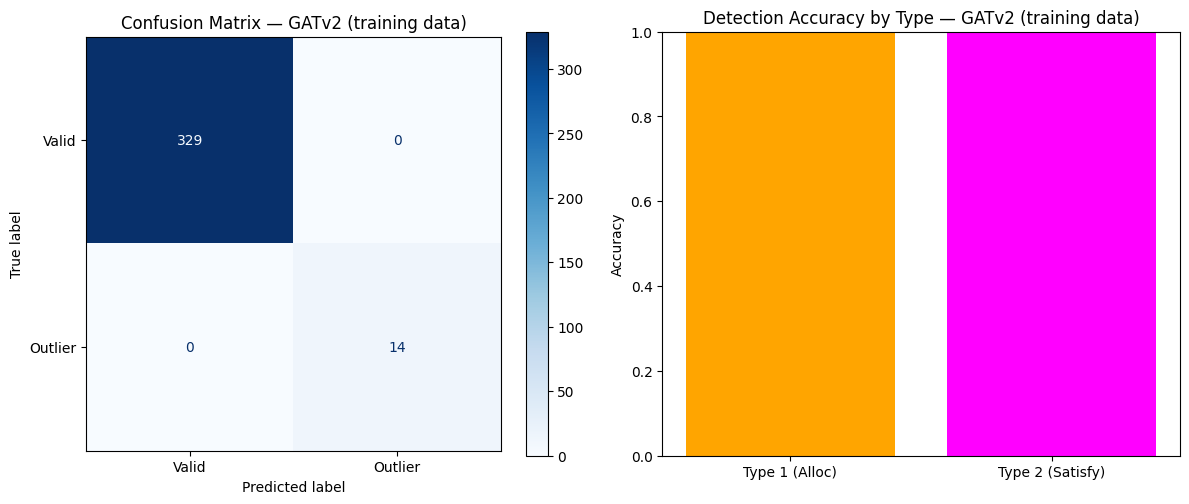

--- Overall Performance (GAT) ---
              precision    recall  f1-score   support

       Valid       1.00      1.00      1.00       329
     Outlier       1.00      1.00      1.00        14

    accuracy                           1.00       343
   macro avg       1.00      1.00      1.00       343
weighted avg       1.00      1.00      1.00       343



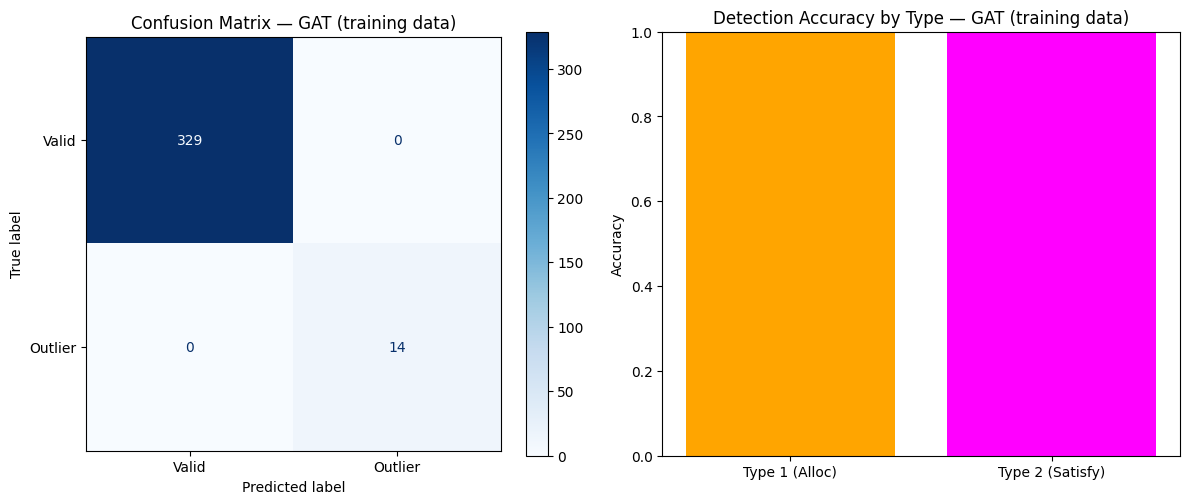

--- Overall Performance (GCN) ---
              precision    recall  f1-score   support

       Valid       1.00      1.00      1.00       329
     Outlier       1.00      1.00      1.00        14

    accuracy                           1.00       343
   macro avg       1.00      1.00      1.00       343
weighted avg       1.00      1.00      1.00       343



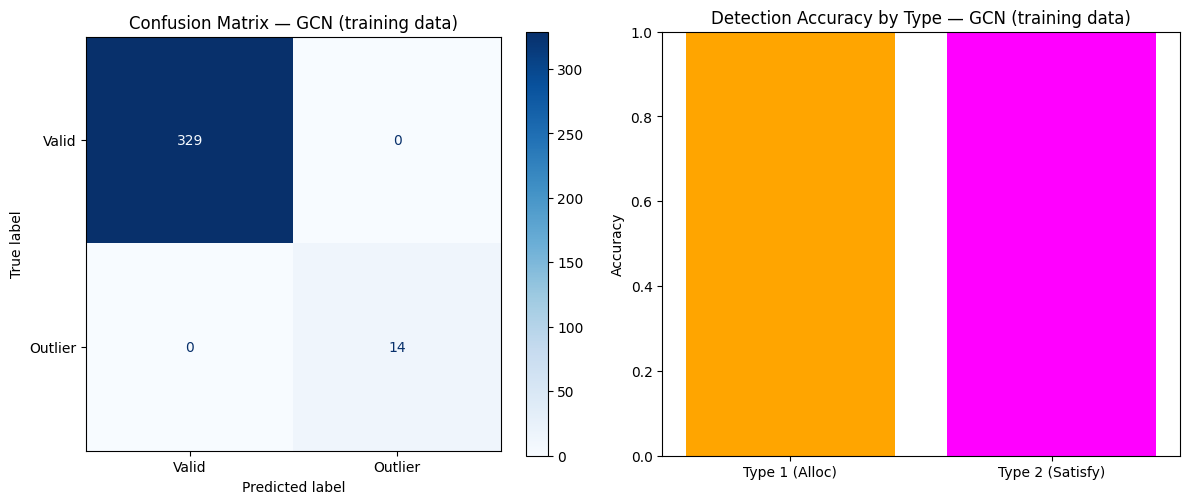

--- Overall Performance (SAGE) ---
              precision    recall  f1-score   support

       Valid       1.00      1.00      1.00       329
     Outlier       1.00      1.00      1.00        14

    accuracy                           1.00       343
   macro avg       1.00      1.00      1.00       343
weighted avg       1.00      1.00      1.00       343



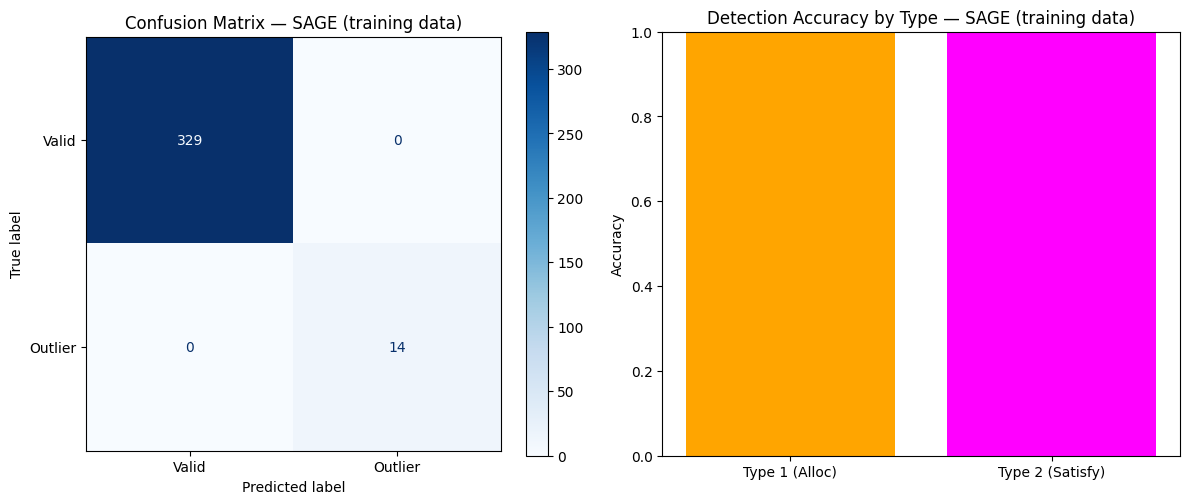

--- Overall Performance (RGCN) ---
              precision    recall  f1-score   support

       Valid       1.00      1.00      1.00       329
     Outlier       1.00      1.00      1.00        14

    accuracy                           1.00       343
   macro avg       1.00      1.00      1.00       343
weighted avg       1.00      1.00      1.00       343



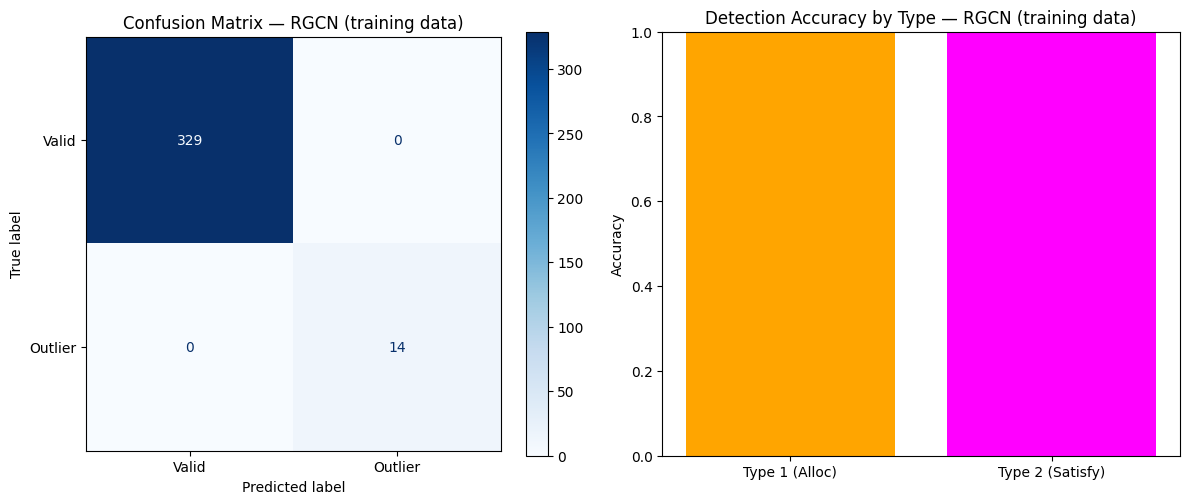

In [21]:
def evaluate_model(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index, data.edge_attr)
        probs  = torch.sigmoid(logits)
        preds  = (probs > 0.5).float()

        y_true = data.y.cpu().numpy()
        y_pred = preds.cpu().numpy()

    cm = confusion_matrix(y_true, y_pred)

    is_alloc   = (data.edge_attr[:, 1] == 1).cpu().numpy()
    is_satisfy = (data.edge_attr[:, 2] == 1).cpu().numpy()

    print(f"--- Overall Performance ({model.gnn_type}) ---")
    print(classification_report(y_true, y_pred, target_names=['Valid', 'Outlier']))

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    ConfusionMatrixDisplay(cm, display_labels=['Valid', 'Outlier']).plot(ax=ax[0], cmap='Blues')
    ax[0].set_title(f"Confusion Matrix — {model.gnn_type} (training data)")

    type1_acc = (y_true[is_alloc]   == y_pred[is_alloc]).mean()   if any(is_alloc)   else 0
    type2_acc = (y_true[is_satisfy] == y_pred[is_satisfy]).mean() if any(is_satisfy) else 0

    ax[1].bar(['Type 1 (Alloc)', 'Type 2 (Satisfy)'], [type1_acc, type2_acc],
              color=['orange', 'magenta'])
    ax[1].set_ylim(0, 1)
    ax[1].set_ylabel('Accuracy')
    ax[1].set_title(f"Detection Accuracy by Type — {model.gnn_type} (training data)")

    plt.tight_layout()
    plt.show()


# Evaluate all active models on training data
for name, model in models.items():
    evaluate_model(model, pyg_dataset)

## 8. Generalization test on unseen graphs

`test_gnn_consolidated` generates fresh graphs the model has never seen and pools results across all of them. This is the primary performance measure.

Test graphs use the same size as training (`req_size=50, func_size=50, comp_size=50`) to avoid an unintentional distribution shift.

Each model produces a consolidated confusion matrix. After all models are tested, a single combined bar chart compares Type 1 and Type 2 accuracy across all architectures.

Run across all active models by iterating `models.items()`.

In [ ]:
def test_gnn_consolidated(model, num_test_graphs=10,
                           req_size=50, func_size=50, comp_size=50):
    """
    Evaluate model on num_test_graphs freshly generated unseen graphs.
    Graph sizes default to match training — change here if you train on larger graphs.
    Returns dict with type1_acc and type2_acc for use in the combined comparison chart.
    """
    model.eval()

    all_y_true, all_y_pred = [], []
    type1_results = {'true': [], 'pred': []}
    type2_results = {'true': [], 'pred': []}

    for _ in range(num_test_graphs):
        g_test = generate_se_dataset_with_outliers(
            req_size=req_size, req_depth=3,
            func_size=func_size, func_depth=4,
            comp_size=comp_size, comp_depth=4
        )
        data_test, _ = convert_to_pyg_data(g_test)

        with torch.no_grad():
            logits = model(data_test.x, data_test.edge_index, data_test.edge_attr)
            preds  = (torch.sigmoid(logits) > 0.5).float()

        all_y_true.append(data_test.y)
        all_y_pred.append(preds)

        is_alloc   = data_test.edge_attr[:, 1] == 1
        is_satisfy = data_test.edge_attr[:, 2] == 1

        type1_results['true'].append(data_test.y[is_alloc])
        type1_results['pred'].append(preds[is_alloc])
        type2_results['true'].append(data_test.y[is_satisfy])
        type2_results['pred'].append(preds[is_satisfy])

    y_true_final = torch.cat(all_y_true).cpu().numpy()
    y_pred_final = torch.cat(all_y_pred).cpu().numpy()

    t1_acc = (torch.cat(type1_results['true']).cpu().numpy() ==
              torch.cat(type1_results['pred']).cpu().numpy()).mean()
    t2_acc = (torch.cat(type2_results['true']).cpu().numpy() ==
              torch.cat(type2_results['pred']).cpu().numpy()).mean()

    # Per-model confusion matrix
    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    cm = confusion_matrix(y_true_final, y_pred_final)
    ConfusionMatrixDisplay(cm, display_labels=['Valid', 'Outlier']).plot(ax=ax, cmap='Blues')
    ax.set_title(f"Consolidated Confusion Matrix — {model.gnn_type} ({num_test_graphs} graphs)")
    plt.tight_layout()
    plt.show()

    return {'model': model.gnn_type, 'type1_acc': t1_acc, 'type2_acc': t2_acc}


# Test all active models on unseen graphs
results = []
for name, model in models.items():
    print(f"\n--- Generalization Test: {name} ---")
    r = test_gnn_consolidated(model, num_test_graphs=10)
    results.append(r)

### Combined comparison chart

After all models are tested, plot Type 1 and Type 2 accuracy side by side for every active architecture. Y-axis starts at 0 so bar heights are honestly proportional.

In [ ]:
model_names      = [r['model'] for r in results]
type1_accuracies = [r['type1_acc'] for r in results]
type2_accuracies = [r['type2_acc'] for r in results]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, type1_accuracies, width,
                label='Type 1 (Allocations)', color='orange')
rects2 = ax.bar(x + width/2, type2_accuracies, width,
                label='Type 2 (Satisfactions)', color='magenta')

ax.set_ylabel('Accuracy')
ax.set_title('Detection Accuracy by Outlier Type — All Architectures (unseen graphs)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1)   # Always start at 0 — truncated axes distort the comparison
ax.legend()

for rects in (rects1, rects2):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2%}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Summary comparison

Prints a ranked summary table of generalization test accuracy across all active models. Re-run the cell above before this one to refresh `results`.

In [20]:
print(f"\n{'='*52}")
print(f"  Architecture Comparison — Unseen Graph Accuracy")
print(f"{'='*52}")
print(f"  {'Model':<10} {'Type 1 (Alloc)':>16} {'Type 2 (Satisfy)':>18}")
print(f"  {'-'*10} {'-'*16} {'-'*18}")

for r in sorted(results, key=lambda x: -(x['type1_acc'] + x['type2_acc'])):
    print(f"  {r['model']:<10} {r['type1_acc']:>15.2%} {r['type2_acc']:>17.2%}")

print(f"{'='*52}")
print()
print("Edge-aware models (GATv2, GAT, RGCN) have direct access to relation")
print("type during message passing. GCN and SAGE infer everything from node")
print("embeddings alone.")


  Architecture Comparison — Unseen Graph Accuracy
  Model        Type 1 (Alloc)   Type 2 (Satisfy)
  ---------- ---------------- ------------------
  SAGE                88.70%            94.03%
  GATv2               89.10%            89.44%
  GAT                 86.20%            91.98%
  RGCN                85.80%            92.21%
  GCN                 89.80%            88.11%

Edge-aware models (GATv2, GAT, RGCN) have direct access to relation
type during message passing. GCN and SAGE infer everything from node
embeddings alone.
